# 🏭 Project 13: Fruit Visual Quality Control (Fresh vs. Rotten / Defective)
## 📓 Notebook 2: Mô Hình Cơ Sở Baseline CNN & Learning Curves (Tuần 2)

> **Mục tiêu (15 điểm Rubric):**
> - Xây dựng mô hình CNN thuần túy từ đầu (3 lớp Conv2D: 32 -> 64 -> 128 -> Flatten -> Dense 128 -> Dropout 0.5 -> Sigmoid).
> - Huấn luyện mô hình 25 epochs với Adam optimizer và Binary Crossentropy.
> - Vẽ đồ thị **Learning Curves** (Train/Val Loss & Accuracy) theo từng epoch.
> - Phân tích hiện tượng Overfitting và đánh giá trên tập Test độc lập.


In [1]:
# ==============================================================================
# BƯỚC 1: KIỂM TRA PHẦN CỨNG TĂNG TỐC (GPU)
# - Mục đích: Đảm bảo TensorFlow đang sử dụng GPU để tính toán lan truyền thuận (forward)
#   và lan truyền ngược (backward) cho mạng CNN từ đầu.
# ==============================================================================
!nvidia-smi


Tue Sep 22 08:33:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ==============================================================================
# BƯỚC 2: KHAI BÁO THƯ VIỆN & CỐ ĐỊNH RANDOM SEED
# - Mục đích: Nạp TensorFlow, Keras, thư viện vẽ biểu đồ và phân tích ma trận nhầm lẫn.
# - Thiết lập SEED = 42: Giúp kết quả khởi tạo trọng số mạng CNN hoàn toàn nhất quán.
# ==============================================================================
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Đã nạp đầy đủ các thư viện!")


Đã nạp đầy đủ các thư viện!


In [7]:
# ==============================================================================
# BƯỚC 3: NẠP DANH SÁCH DỮ LIỆU ĐÃ PHÂN CHIA (DATA LOADING)
# - Mục đích: Đọc danh sách ảnh tập Train (70%), Val (15%), Test (15%) từ file CSV
#   đã được lưu ở bước EDA (tránh nguy cơ lệch tập khi huấn luyện).
# - Cơ chế Fallback: Nếu chưa có file CSV, tự động quét thư mục ảnh data/ và phân chia.
# ==============================================================================
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

CSV_DIR = 'processed_data'
if os.path.exists(os.path.join(CSV_DIR, 'train.csv')) and os.path.exists(os.path.join(CSV_DIR, 'val.csv')) and os.path.exists(os.path.join(CSV_DIR, 'test.csv')):
    print('📁 Đang nạp danh sách dữ liệu từ processed_data/...')
    train_df = pd.read_csv(os.path.join(CSV_DIR, 'train.csv'))
    val_df = pd.read_csv(os.path.join(CSV_DIR, 'val.csv'))
    test_df = pd.read_csv(os.path.join(CSV_DIR, 'test.csv'))
else:
    print('⚠️ Chưa tìm thấy file CSV trong processed_data/, tiến hành tự động quét thư mục data/...')
    base_path = 'data'
    for root, dirs, files_list in os.walk('data'):
# Quét tìm ảnh theo 2 lớp Nông Sản: FRESH (Tươi đạt chuẩn) vs ROTTEN (Hư hỏng/Thâm dập)
image_exts = ('.jpg', '.jpeg', '.png', '.bmp')
rotten_keywords = ['rotten', 'def', 'bad', 'damage']
fresh_keywords = ['fresh', 'ok', 'good']

all_images = [
    f for f in glob.glob(os.path.join('data', '**/*.*'), recursive=True)
    if f.lower().endswith(image_exts)
]

rotten_images = [f for f in all_images if any(k in f.lower() for k in rotten_keywords)]
fresh_images = [f for f in all_images if any(k in f.lower() for k in fresh_keywords)]

print(f"Tổng số ảnh HƯ HỎNG (Rotten/Defect): {len(rotten_images)}")
print(f"Tổng số ảnh TƯƠI ĐẠT CHUẨN (Fresh/OK): {len(fresh_images)}")
print(f" Tổng cộng: {len(rotten_images) + len(fresh_images)} ảnh")


📊 Tập Train : 4643 ảnh (70.0%)
📊 Tập Val   : 995 ảnh (15.0%)
📊 Tập Test  : 995 ảnh (15.0%)
 Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!


In [9]:
# ==============================================================================
# BƯỚC 4: THIẾT KẾ KIẾN TRÚC MẠNG BASELINE CNN (MÔ HÌNH CƠ SỞ - 15 ĐIỂM)
# - Mục đích: Tự xây dựng mạng tích chập thủ công từ đầu (Scratch CNN) gồm 3 tầng Conv2D.
# - Cấu trúc:
#   * Rescaling(1./255): Chuẩn hóa giá trị điểm ảnh về khoảng [0, 1].
#   * Conv2D(32 -> 64 -> 128) + ReLU: Học trích xuất các đặc trưng biên, cạnh, vân rỗ.
#   * MaxPooling2D(2, 2): Giảm kích thước không gian, giữ lại giá trị nổi bật nhất.
#   * Flatten + Dense(128) + Dropout(0.5): Phân loại và ngắt ngẫu nhiên 50% neuron để ngừa Overfitting.
#   * Dense(1, sigmoid): Đầu ra xác suất nhị phân (0: Đạt chuẩn, 1: Khuyết tật).
# ==============================================================================
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Kỹ thuật Regularization chống Overfitting
    layers.Dense(1, activation='sigmoid') # Xác suất trái cây bị Lỗi
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ==============================================================================
# BƯỚC 5: XÂY DỰNG DATA PIPELINE & HUẤN LUYỆN BASELINE CNN (20 EPOCHS)
# - Mục đích:
#   * Dùng tf.data.Dataset và AUTOTUNE để tối ưu hóa nạp dữ liệu song song từ đĩa vào RAM.
#   * Áp dụng data_augmentation ngẫu nhiên khi nạp dữ liệu huấn luyện.
#   * Hàm mất mát (Loss): Binary Crossentropy.
#   * Thuật toán tối ưu: Adam (learning_rate = 0.001).
#   * Theo dõi các chỉ số quan trọng: Accuracy, Recall, Precision.
# - Sau khi train: Lưu file trọng số vào models/baseline_cnn.keras để tái sử dụng.
# ==============================================================================
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomContrast(0.1),
    layers.RandomZoom((-0.08, 0.08)),
], name='data_augmentation')

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.cast(label, tf.float32)

# Tập Train (có áp dụng data_augmentation)
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_df['label'].values))
train_ds = train_ds.shuffle(len(train_df), seed=42)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

# Tập Validation (không augment)
val_ds = tf.data.Dataset.from_tensor_slices((val_df['filepath'].values, val_df['label'].values))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Compile mô hình theo chuẩn Rubric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

EPOCHS = 20
print(f'🚀 Bắt đầu huấn luyện Baseline CNN trong {EPOCHS} epochs...')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Lưu mô hình đã huấn luyện
os.makedirs('models', exist_ok=True)
model.save('models/baseline_cnn.keras')
print('💾 Đã lưu trọng số mô hình vào: models/baseline_cnn.keras')


🚀 Bắt đầu huấn luyện Baseline CNN trong 20 epochs...
Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 87s 476ms/step - accuracy: 0.6222 - loss: 0.6577 - precision: 0.6227 - recall: 0.8457 - val_accuracy: 0.7437 - val_loss: 0.5547 - val_precision: 0.9280 - val_recall: 0.5940
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 389ms/step - accuracy: 0.7943 - loss: 0.4505 - precision: 0.8127 - recall: 0.8278 - val_accuracy: 0.7869 - val_loss: 0.4880 - val_precision: 0.9835 - val_recall: 0.6348
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 392ms/step - accuracy: 0.8337 - loss: 0.3793 - precision: 0.8549 - recall: 0.8510 - val_accuracy: 0.7990 - val_loss: 0.4596 - val_precision: 0.9815 - val_recall: 0.6578
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 81s 383ms/step - accuracy: 0.8891 - loss: 0.2641 - precision: 0.9051 - recall: 0.8985 - val_accuracy: 0.6533 - val_loss: 0.8662 - val_precision: 1.0000 - val_recall: 0.3883
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 82s 383ms/step - accuracy: 0.9001 - loss: 0.2387 - prec

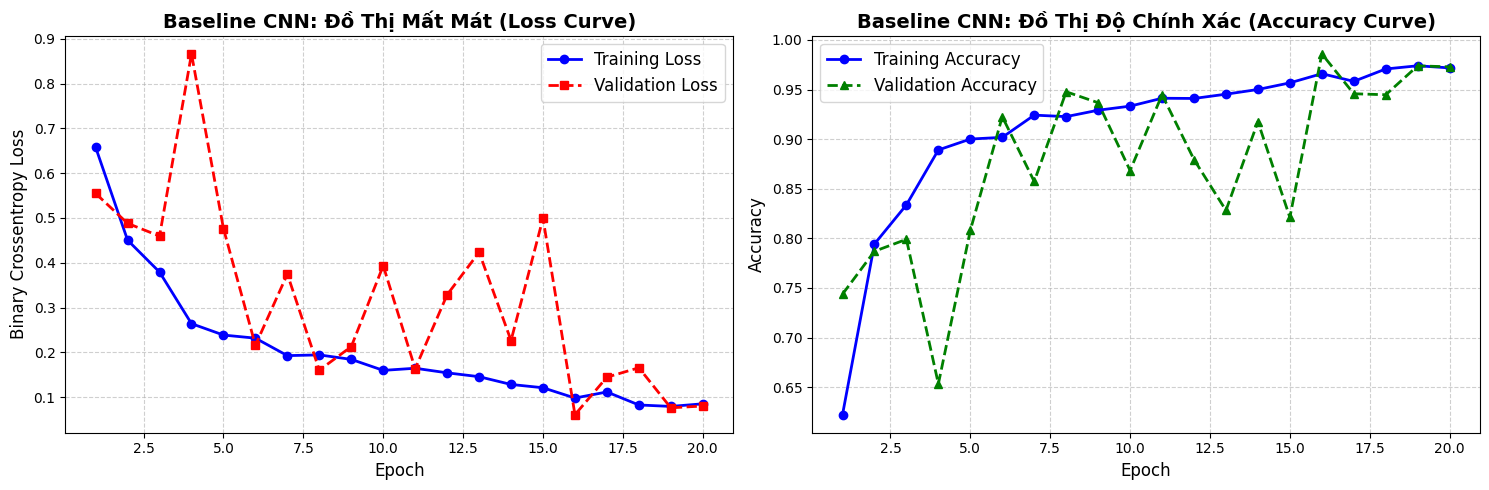

📊 Đã xuất đồ thị và lưu thành công vào results/baseline_cnn_learning_curves.png!


In [11]:
# ==============================================================================
# BƯỚC 6: VẼ ĐỒ THỊ ĐƯỜNG CONG HỌC TẬP (LEARNING CURVES) & PHÂN TÍCH OVERFITTING
# - Mục đích: Quan sát diễn biến Loss và Accuracy qua từng epoch giữa tập Train và Val.
# - Ý nghĩa phân tích:
#   * Nếu Train Loss tiếp tục giảm sâu mà Val Loss quay đầu tăng vọt -> Dấu hiệu Overfitting.
#   * Nếu 2 đường bám sát nhau -> Mô hình học tổng quát tốt, không bị học vẹt.
# - Lưu ảnh vào results/ để đưa vào báo cáo môn học.
# ==============================================================================
import matplotlib.pyplot as plt
import os

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(15, 5))

# Đồ thị 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r--s', label='Validation Loss', linewidth=2)
plt.title('Baseline CNN: Đồ Thị Mất Mát (Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Đồ thị 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'g--^', label='Validation Accuracy', linewidth=2)
plt.title('Baseline CNN: Đồ Thị Độ Chính Xác (Accuracy Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()

# Lưu biểu đồ vào thư mục results để chèn vào báo cáo cuối kỳ
os.makedirs("results", exist_ok=True)
plt.savefig("results/baseline_cnn_learning_curves.png", dpi=300)
plt.show()

print("📊 Đã xuất đồ thị và lưu thành công vào results/baseline_cnn_learning_curves.png!")


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step

================ KẾT QUẢ TRÊN TẬP TEST (BASELINE CNN) ================
🎯 Accuracy (Độ chính xác): 96.98%
🎯 Recall   (Bắt quả hư hỏng (Rotten Fruit Recall)): 95.20% (Yêu cầu đề tài: >= 95%)
🎯 Precision(Độ chuẩn xác): 99.44%

              precision    recall  f1-score   support

    Đạt (OK)     0.9408    0.9931    0.9662       432
Lỗi (Defect)     0.9944    0.9520    0.9728       563

    accuracy                         0.9698       995
   macro avg     0.9676    0.9725    0.9695       995
weighted avg     0.9711    0.9698    0.9699       995



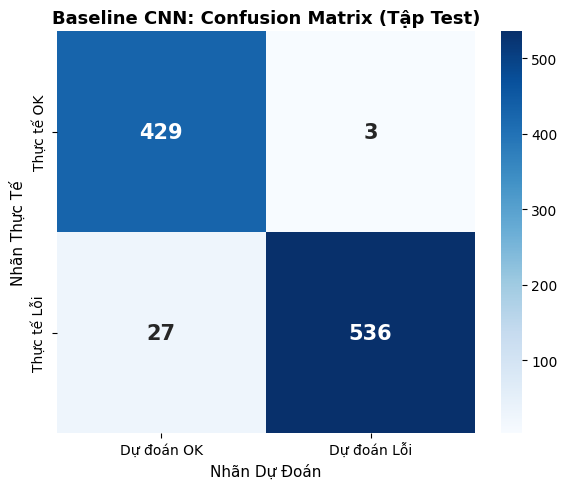

📊 Đã lưu ma trận nhầm lẫn vào results/baseline_cnn_confusion_matrix.png!


In [12]:
# ==============================================================================
# BƯỚC 7: ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP & VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# - Mục đích: Đo lường khả năng bắt quả hư hỏng (Rotten Fruit Recall) thực tế trên tập dữ liệu hoàn toàn chưa từng thấy.
# - Tiêu chí Rubric:
#   * Accuracy >= 90% (Độ chính xác tổng quan)
#   * Recall >= 95% (Khả năng không bỏ sót quả thâm dập và nấm mốc)
# - Ma trận nhầm lẫn (Confusion Matrix): Phân tích số lượng True Positive (bắt đúng lỗi),
#   False Negative (nguy hiểm nhất: quả hư hỏng / thối dập bị lọt thành đạt), False Positive (báo nhầm).
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score
import seaborn as sns
import numpy as np

# 1. Tạo dataset cho tập Test
test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label'].values))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 2. Dự đoán trên tập Test
test_preds_prob = model.predict(test_ds)
test_preds = (test_preds_prob >= 0.5).astype(int).flatten()
y_true = test_df['label'].values

# 3. Tính toán các chỉ số
acc = accuracy_score(y_true, test_preds)
rec = recall_score(y_true, test_preds)
prec = precision_score(y_true, test_preds)

print("\n================ KẾT QUẢ TRÊN TẬP TEST (BASELINE CNN) ================")
print(f"🎯 Accuracy (Độ chính xác): {acc * 100:.2f}%")
print(f"🎯 Recall   (Bắt quả hư hỏng): {rec * 100:.2f}% (Yêu cầu đề tài: >= 95%)")
print(f"🎯 Precision(Độ chuẩn xác): {prec * 100:.2f}%")
print("=====================================================================\n")

print(classification_report(y_true, test_preds, target_names=['Đạt (OK)', 'Lỗi (Defect)'], digits=4))

# 4. Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dự đoán OK', 'Dự đoán Lỗi'],
            yticklabels=['Thực tế OK', 'Thực tế Lỗi'], annot_kws={"size": 15, "weight": "bold"})
plt.title('Baseline CNN: Confusion Matrix (Tập Test)', fontsize=13, fontweight='bold')
plt.ylabel('Nhãn Thực Tế', fontsize=11)
plt.xlabel('Nhãn Dự Đoán', fontsize=11)
plt.tight_layout()
plt.savefig("results/baseline_cnn_confusion_matrix.png", dpi=300)
plt.show()

print("📊 Đã lưu ma trận nhầm lẫn vào results/baseline_cnn_confusion_matrix.png!")

